In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
df=pd.read_csv('/kaggle/input/datasets/nabinpaaudel/standardscaler/Social_Network_Ads.csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [2]:
df=df.iloc[:,2:5]
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [3]:
X=df.drop(columns=['Purchased'])
y=df['Purchased']
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=0)

In [4]:
X_train.shape,y_train.shape

((320, 2), (320,))

# Scaling

In [5]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(X_train)
X_train_scaled=scaler.transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [6]:
X_train_scaled=pd.DataFrame(X_train_scaled,columns=X_train.columns)
X_test_scaled=pd.DataFrame(X_test_scaled,columns=X_test.columns)

In [7]:
np.round(X_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-1.6
25%,-0.8,-0.8
50%,-0.0,-0.0
75%,0.8,0.5
max,2.1,2.3


In [8]:
X_train.describe()

,Age,EstimatedSalary
count,320.00000,320.000000
mean,38.21875,69928.125000
std,10.30304,34570.057299
min,18.00000,15000.000000
25%,30.00000,43000.000000
50%,38.00000,69500.000000
75%,46.00000,88000.000000
max,60.00000,150000.000000


# Comparing

Text(0.5, 1.0, 'After Scaling')

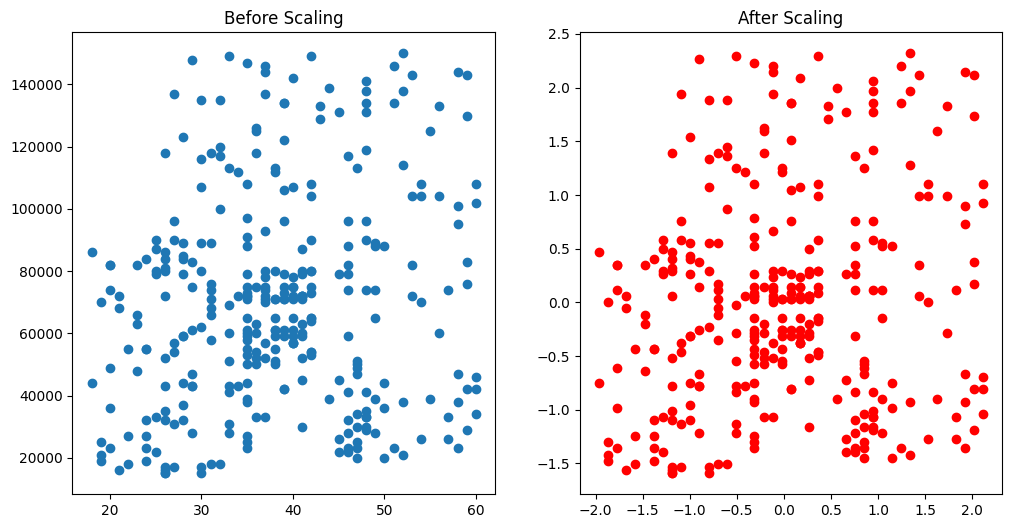

In [9]:
fig ,axs=plt.subplots(1,2,figsize=(12,6))
axs[0].scatter(X_train['Age'],X_train['EstimatedSalary'])
axs[0].set_title('Before Scaling')
axs[1].scatter(X_train_scaled['Age'],X_train_scaled['EstimatedSalary'],c='r')
axs[1].set_title('After Scaling')

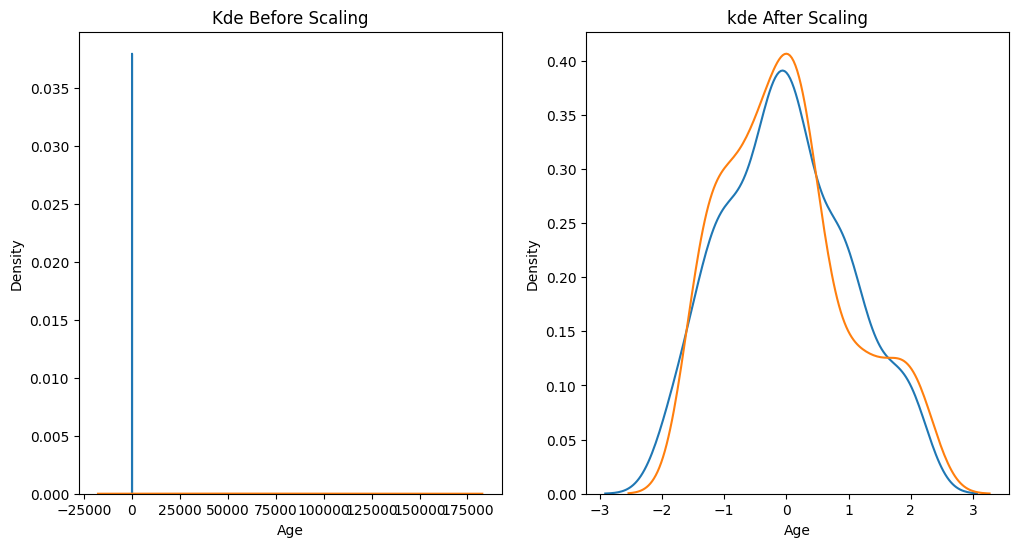

In [10]:
fig,axs=plt.subplots(1,2,figsize=(12,6))
sns.kdeplot(x='Age',data=X_train,ax=axs[0])
sns.kdeplot(x='EstimatedSalary',data=X_train,ax=axs[0])
axs[0].set_title('Kde Before Scaling')
sns.kdeplot(x='Age',data=X_train_scaled,ax=axs[1])
sns.kdeplot(x='EstimatedSalary',data=X_train_scaled,ax=axs[1])
axs[1].set_title('kde After Scaling')
plt.show()

Text(0.5, 1.0, 'Age After Scaling')

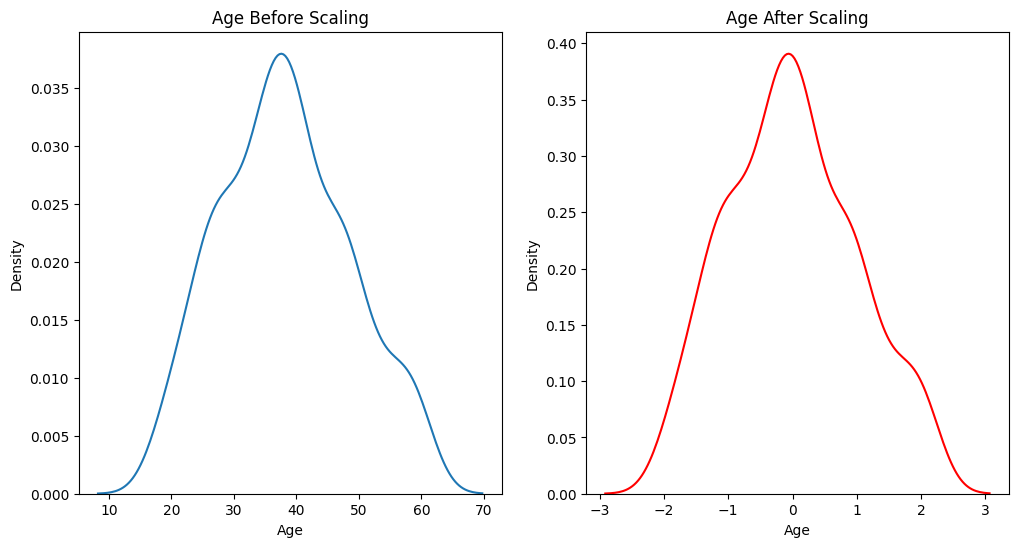

In [11]:
fig,axs=plt.subplots(1,2,figsize=(12,6))
sns.kdeplot(X_train['Age'],ax=axs[0])
axs[0].set_title('Age Before Scaling')
sns.kdeplot(X_train_scaled['Age'],ax=axs[1],c='r')
axs[1].set_title('Age After Scaling')

Text(0.5, 1.0, 'Estimated Salary After Scaling')

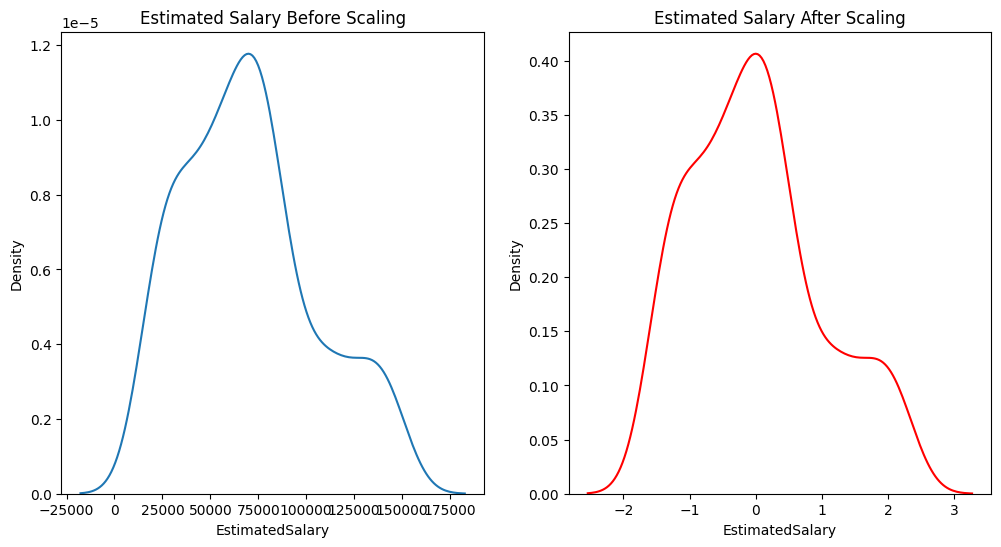

In [12]:
fig,axs=plt.subplots(1,2,figsize=(12,6))
sns.kdeplot(X_train['EstimatedSalary'],ax=axs[0])
axs[0].set_title('Estimated Salary Before Scaling')
sns.kdeplot(X_train_scaled['EstimatedSalary'],ax=axs[1],c='r')
axs[1].set_title('Estimated Salary After Scaling')

# Why Scaling is important

In [13]:
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr_scaled=LogisticRegression()

In [14]:
lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

LogisticRegression()

In [15]:
y_pred=lr.predict(X_test)
y_pred_scaled=lr_scaled.predict(X_test_scaled)

In [16]:
from sklearn.metrics import accuracy_score

In [17]:
print('Actual',accuracy_score(y_test,y_pred)*100)
print('Scaled',accuracy_score(y_test,y_pred_scaled)*100)

Actual 91.25
Scaled 92.5
